# Deteccion de maximo enfoque en dominio frecuencial

Implementación de la metrica propuesta en el paper:
> "Image Sharpness Measure for Blurred Images in Frequency Domain"  
> Kanjar De & V. Masilamani, Procedia Engineering 64 (2013) 149–158

La metrica evalua que fracción espectral corresponde a componentes de alta frecuencia:

$$FM = \frac{\displaystyle\sum_{u,v} |F(u,v)|^2 \cdot \mathbf{1}[|F(u,v)| > T_{th}]}{\displaystyle\sum_{u,v} |F(u,v)|^2}$$

donde $F(u,v)$ es la DFT 2D de la imagen en escala de grises y $T_{th} = r \cdot \max|F|$ con $r$ pequeño (paper: $r \approx 0.001\text{–}0.01$).

Imágenes nítidas  >> más energía en altas frecuencias >> FM alto  
Imágenes desenfocadas >> altas frecuencias atenuadas >> FM bajo

## 0. Importaciones y configuración

In [43]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

# ── Parámetros ────────────────────────────────────────────────────────────────
VIDEO_PATH         = 'focus_video.mov'   # video a procesar
THRESHOLD_RATIO    = 0.005               # r del paper (fracción del máximo espectral)
ROI_AREA_FRACTION  = 0.10               # área de la ROI = 10% del frame
SMOOTH_WINDOW      = 7                   # ventana (frames) para suavizado de la curva FM

print('Librerías cargadas correctamente.')
print(f'Parámetros: threshold_ratio={THRESHOLD_RATIO}, ROI={ROI_AREA_FRACTION*100:.0f}%, smooth_window={SMOOTH_WINDOW}')

Librerías cargadas correctamente.
Parámetros: threshold_ratio=0.005, ROI=10%, smooth_window=7


## 1. Funciones: métrica FM y detección de picos

In [44]:
def sharpness_metric(image_gray, threshold_ratio=THRESHOLD_RATIO):
    """
    nitidez en dominio frecuencial según De & Masilamani (2013).
    image_gray     : ndarray   imagen en grises (uint8 o float)
    threshold_ratio: float     fracción del máximo del espectro usada como umbral T_th

    Retorna:  fm : float   métrica de enfoque E (0,1]  — mayor es más nitida
    """
    F         = np.fft.fft2(image_gray.astype(np.float64))
    F_shift   = np.fft.fftshift(F)
    magnitude = np.abs(F_shift)

    T_th      = threshold_ratio * magnitude.max()
    total_E   = np.sum(magnitude ** 2)
    high_E    = np.sum((magnitude ** 2) * (magnitude > T_th))

    return high_E / (total_E + 1e-12)


def smooth_signal(signal, window=SMOOTH_WINDOW):
    """Suaviza la señal con filtro de media uniforme (igual al del paper)."""
    return uniform_filter1d(signal.astype(float), size=window)


def detect_focus_peaks(metrics, smooth_window=SMOOTH_WINDOW, min_distance=10):
    """
    Detecta frames de máximo enfoque
    1.Suaviza la curva FM para eliminar ruido de alta frecuencia
    2.Usa scipy.find_peaks con en el rango real de la señal suavizada
    3. Si no se detectan picos (curva plana) devuelve el máximo global

    peaks_raw   : indices sobre la señal ORIGINAL (sin suavizar)
    peaks_smooth: indices sobre la señal SUAVIZADA
    metrics_s   : señal suavizada
    """
    metrics_s = smooth_signal(np.array(metrics), smooth_window)
    rango     = metrics_s.max() - metrics_s.min()

    # Prominencia mínima: 5% del rango (detecta picos amplios)
    prominence = max(0.05 * rango, 1e-6)

    peaks_smooth, props = find_peaks(metrics_s,
                                     prominence=prominence,
                                     distance=min_distance)

    # Si no hay picos, el máximo global ES el punto de enfoque
    if len(peaks_smooth) == 0:
        peaks_smooth = np.array([np.argmax(metrics_s)])

    # Mapear cada pico suavizado al máximo real en una ventana ±smooth_window
    metrics_raw = np.array(metrics)
    peaks_raw   = []
    for p in peaks_smooth:
        lo = max(0, p - smooth_window)
        hi = min(len(metrics_raw)-1, p + smooth_window)
        peaks_raw.append(lo + np.argmax(metrics_raw[lo:hi+1]))
    peaks_raw = np.array(peaks_raw)

    return peaks_raw, peaks_smooth, metrics_s

print('Funciones definidas.')

Funciones definidas.


## 2. Lectura del video e información

In [45]:
cap = cv.VideoCapture(VIDEO_PATH)

TOTAL_FRAMES = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
FPS = cap.get(cv.CAP_PROP_FPS)
WIDTH= int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f'Video: {VIDEO_PATH}')
print(f'Resolucion: {WIDTH} x {HEIGHT} px ,  {TOTAL_FRAMES} frames  ,  {FPS:.2f} FPS')
print(f'Duración: {TOTAL_FRAMES/FPS:.2f} s')

# ── ROI central ──────────────────────────────────────────────────────────────
roi_side = int(np.sqrt(ROI_AREA_FRACTION * WIDTH * HEIGHT))
roi_x1   = (WIDTH  - roi_side) // 2
roi_y1   = (HEIGHT - roi_side) // 2
roi_x2   = roi_x1 + roi_side
roi_y2   = roi_y1 + roi_side

print(f'\nROI central ({ROI_AREA_FRACTION*100:.0f}% área): '
      f'({roi_x1},{roi_y1}) -> ({roi_x2},{roi_y2})    {roi_side}×{roi_side} px  '
      f'({roi_side**2/(WIDTH*HEIGHT)*100:.1f}% real)')

Video: focus_video.mov
Resolucion: 640 x 360 px ,  171 frames  ,  29.97 FPS
Duración: 5.71 s

ROI central (10% área): (244,104) -> (395,255)    151×151 px  (9.9% real)


## 3. FM para cada frame

In [46]:
metrics_full = []
metrics_roi  = []

cap = cv.VideoCapture(VIDEO_PATH)
print('Procesando frames', end='')
for i in range(TOTAL_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Experimento 1: frame completo
    metrics_full.append(sharpness_metric(gray))

    # Experimento 2: ROI central
    roi = gray[roi_y1:roi_y2, roi_x1:roi_x2]
    metrics_roi.append(sharpness_metric(roi))

    if (i+1) % 30 == 0:
        print(f' {i+1}', end='')

cap.release()

metrics_full  = np.array(metrics_full)
metrics_roi   = np.array(metrics_roi)
frame_indices = np.arange(TOTAL_FRAMES)
time_axis     = frame_indices / FPS

print(f'\n\n{len(metrics_full)} frames procesados.')
print(f'FM frame completo — min: {metrics_full.min():.6f} (F{metrics_full.argmin()})  '
      f'max: {metrics_full.max():.6f} (F{metrics_full.argmax()})')
print(f'FM ROI central    — min: {metrics_roi.min():.6f} (F{metrics_roi.argmin()})  '
      f'max: {metrics_roi.max():.6f} (F{metrics_roi.argmax()})')

Procesando frames 30 60 90 120 150

171 frames procesados.
FM frame completo — min: 0.970998 (F109)  max: 0.993203 (F18)
FM ROI central    — min: 0.969698 (F102)  max: 0.996688 (F23)


## 4. Detección de picos de enfoque

In [47]:
peaks_full_raw, peaks_full_s, metrics_full_s = detect_focus_peaks(metrics_full)
peaks_roi_raw,  peaks_roi_s,  metrics_roi_s  = detect_focus_peaks(metrics_roi)

def report(name, peaks_raw, metrics, time_axis):
    print(f'  Picos detectados: {len(peaks_raw)}')
    for p in peaks_raw:
        print(f'  Frame {p:3d}    t = {time_axis[p]:.2f} s    FM = {metrics[p]:.6f}')
    best = peaks_raw[np.argmax(metrics[peaks_raw])]
    print(f'  Máximo de enfoque: Frame {best}  (t = {time_axis[best]:.2f} s)  FM = {metrics[best]:.6f}')
    return best

print('-Experimento 1: Frame completo ')
best_full = report('Exp1', peaks_full_raw, metrics_full, time_axis)

print()
print('- Experimento 2: ROI central')
best_roi = report('Exp2', peaks_roi_raw, metrics_roi, time_axis)

-Experimento 1: Frame completo 
  Picos detectados: 1
  Frame 156    t = 5.21 s    FM = 0.993141
  Máximo de enfoque: Frame 156  (t = 5.21 s)  FM = 0.993141

- Experimento 2: ROI central
  Picos detectados: 1
  Frame  23    t = 0.77 s    FM = 0.996688
  Máximo de enfoque: Frame 23  (t = 0.77 s)  FM = 0.996688


## 5. Experimento 1. Metrica sobre el frame completo

Se muestra la curva FM bruta y suavizada frame a frame, con los picos detectados marcados.

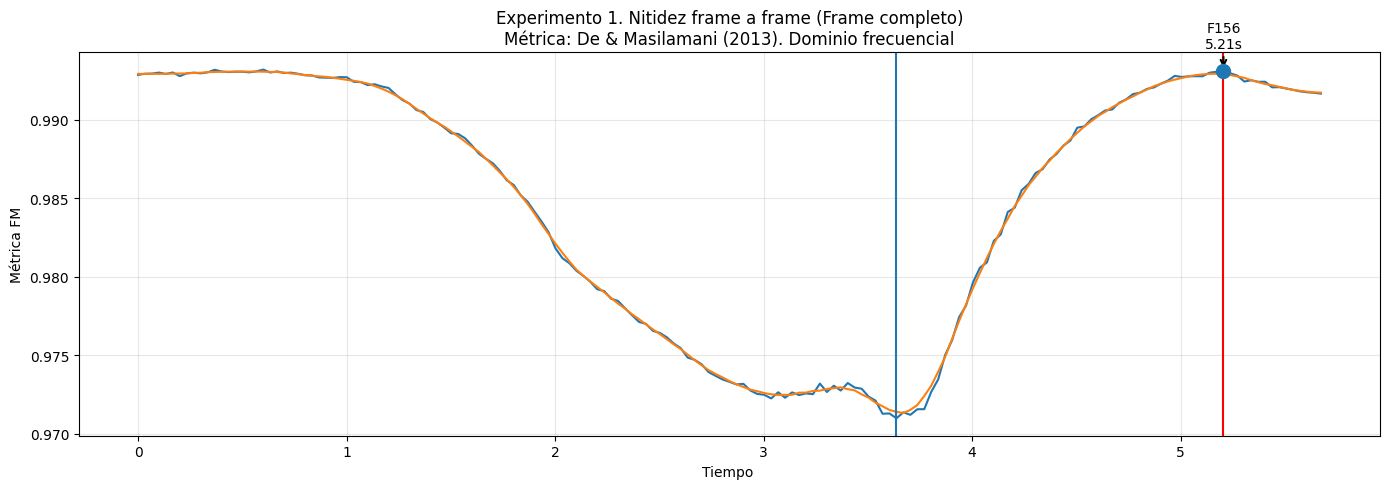

Figura guardada: exp1_frame_completo.png


In [48]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time_axis, metrics_full,   label='FM bruto')
ax.plot(time_axis, metrics_full_s, label=f'FM suavizado (ventana={SMOOTH_WINDOW} frames)')

# Picos detectados
ax.scatter(time_axis[peaks_full_raw], metrics_full[peaks_full_raw], s=100, zorder=6, label='Pico detectado')

for p in peaks_full_raw:
    ax.annotate(f'F{p}\n{time_axis[p]:.2f}s',
                xy=(time_axis[p], metrics_full[p]),
                xytext=(0, 16), textcoords='offset points',
                ha='center', arrowprops=dict(arrowstyle='->', lw=1.5)  )

# Línea vertical en el máximo
ax.axvline(time_axis[best_full], color='red',  label=f'Máximo enfoque: F{best_full} ({time_axis[best_full]:.2f} s)')

# Mínimo (máximo desenfoque)
worst_full = metrics_full.argmin()
ax.axvline(time_axis[worst_full],  label=f'Mínimo enfoque: F{worst_full} ({time_axis[worst_full]:.2f} s)')

ax.set_xlabel('Tiempo ')
ax.set_ylabel('Métrica FM')
ax.set_title('Experimento 1. Nitidez frame a frame (Frame completo)\n'
             'Métrica: De & Masilamani (2013). Dominio frecuencial')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp1_frame_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: exp1_frame_completo.png')

## 6. Experimento 2: Métrica sobre la ROI central (10% área)

La ROI cuadrada centrada reduce el cómputo y focaliza el análisis en la zona de interés central.

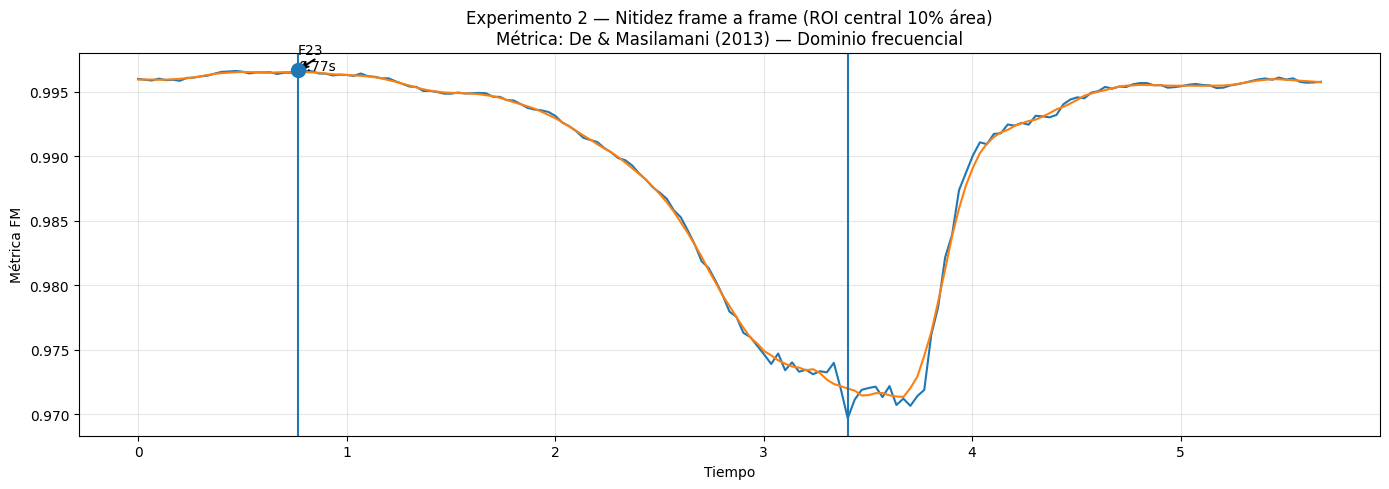

Figura guardada: exp2_roi_central.png


In [49]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time_axis, metrics_roi,   label='FM bruto')
ax.plot(time_axis, metrics_roi_s, label=f'FM suavizado (ventana={SMOOTH_WINDOW} frames)')

ax.scatter(time_axis[peaks_roi_raw], metrics_roi[peaks_roi_raw], s=100, zorder=6, label='Pico detectado')

for p in peaks_roi_raw:
    ax.annotate(f'F{p}\n{time_axis[p]:.2f}s', xy=(time_axis[p], metrics_roi[p]), arrowprops=dict(arrowstyle='->', lw=1.5) )

ax.axvline(time_axis[best_roi], label=f'Máximo enfoque: F{best_roi} ({time_axis[best_roi]:.2f} s)')

worst_roi = metrics_roi.argmin()
ax.axvline(time_axis[worst_roi], label=f'Mínimo enfoque: F{worst_roi} ({time_axis[worst_roi]:.2f} s)')

ax.set_xlabel('Tiempo')
ax.set_ylabel('Métrica FM')
ax.set_title(f'Experimento 2 — Nitidez frame a frame (ROI central {ROI_AREA_FRACTION*100:.0f}% área)\n'
             'Métrica: De & Masilamani (2013) — Dominio frecuencial')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp2_roi_central.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: exp2_roi_central.png')

## 7. Comparación superpuesta: Experimento 1 vs Experimento 2

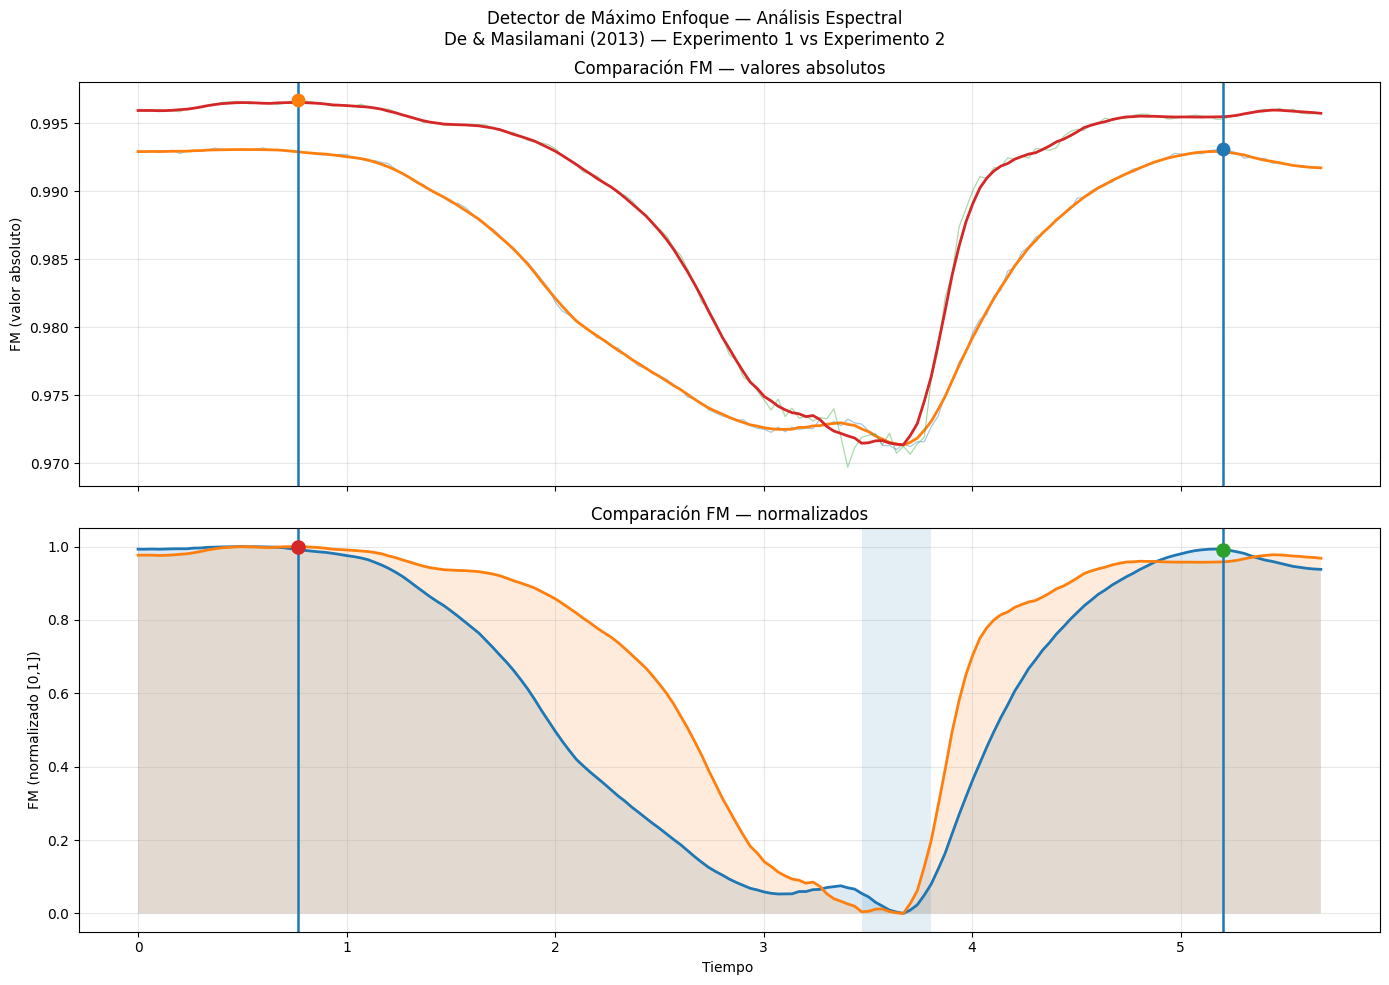

Figura guardada: comparacion_experimentos.png


In [50]:
def normalize01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Panel superior: valores absolutos ──────────────────────────────────────
ax1 = axes[0]
ax1.plot(time_axis, metrics_full,   lw=0.9, alpha=0.4)
ax1.plot(time_axis, metrics_full_s, lw=2.0, label='Frame completo (suavizado)')
ax1.plot(time_axis, metrics_roi,   lw=0.9, alpha=0.4)
ax1.plot(time_axis, metrics_roi_s, lw=2.0,  label=f'ROI {ROI_AREA_FRACTION*100:.0f}% (suavizado)')

for p in peaks_full_raw:
    ax1.scatter(time_axis[p], metrics_full[p],  s=80, zorder=5)
for p in peaks_roi_raw:
    ax1.scatter(time_axis[p], metrics_roi[p],  s=80, zorder=5)

ax1.axvline(time_axis[best_full],lw=1.8, label=f'Máx. completo F{best_full} ({time_axis[best_full]:.2f}s)')
ax1.axvline(time_axis[best_roi], lw=1.8, label=f'Máx. ROI F{best_roi} ({time_axis[best_roi]:.2f}s)')

ax1.set_ylabel('FM (valor absoluto)')
ax1.set_title('Comparación FM — valores absolutos')
ax1.grid(True, alpha=0.3)

# Panel inferior: normalizados 
ax2 = axes[1]
norm_full = normalize01(metrics_full_s)
norm_roi  = normalize01(metrics_roi_s)

ax2.fill_between(time_axis, norm_full, alpha=0.15 )
ax2.fill_between(time_axis, norm_roi,  alpha=0.15)
ax2.plot(time_axis, norm_full, lw=2.0, label='Frame completo (norm.)')
ax2.plot(time_axis, norm_roi,  lw=2.0, label=f'ROI {ROI_AREA_FRACTION*100:.0f}% (norm.)')

ax2.scatter(time_axis[peaks_full_raw], norm_full[peaks_full_raw], s=90, zorder=5)
ax2.scatter(time_axis[peaks_roi_raw],  norm_roi[peaks_roi_raw], s=90, zorder=5)

ax2.axvline(time_axis[best_full], lw=1.8, label=f'Máx. completo F{best_full}')
ax2.axvline(time_axis[best_roi],    lw=1.8, label=f'Máx. ROI F{best_roi}')

# Zona de mínimo enfoque
worst_full = metrics_full.argmin()
ax2.axvspan(time_axis[max(0,worst_full-5)], time_axis[min(TOTAL_FRAMES-1,worst_full+5)],
            alpha=0.12, label='Zona de mínimo enfoque')

ax2.set_xlabel('Tiempo ')
ax2.set_ylabel('FM (normalizado [0,1])')
ax2.set_title('Comparación FM — normalizados')

ax2.grid(True, alpha=0.3)

plt.suptitle('Detector de Máximo Enfoque — Análisis Espectral\n'
             'De & Masilamani (2013) — Experimento 1 vs Experimento 2')
plt.tight_layout()
plt.savefig('comparacion_experimentos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_experimentos.png')

## 8. Visualización de frames clave y sus espectros

Comparación visual entre el frame más desenfocado, el frame en que se detecta el máximo enfoque,
y el espectro de Fourier correspondiente a cada uno.

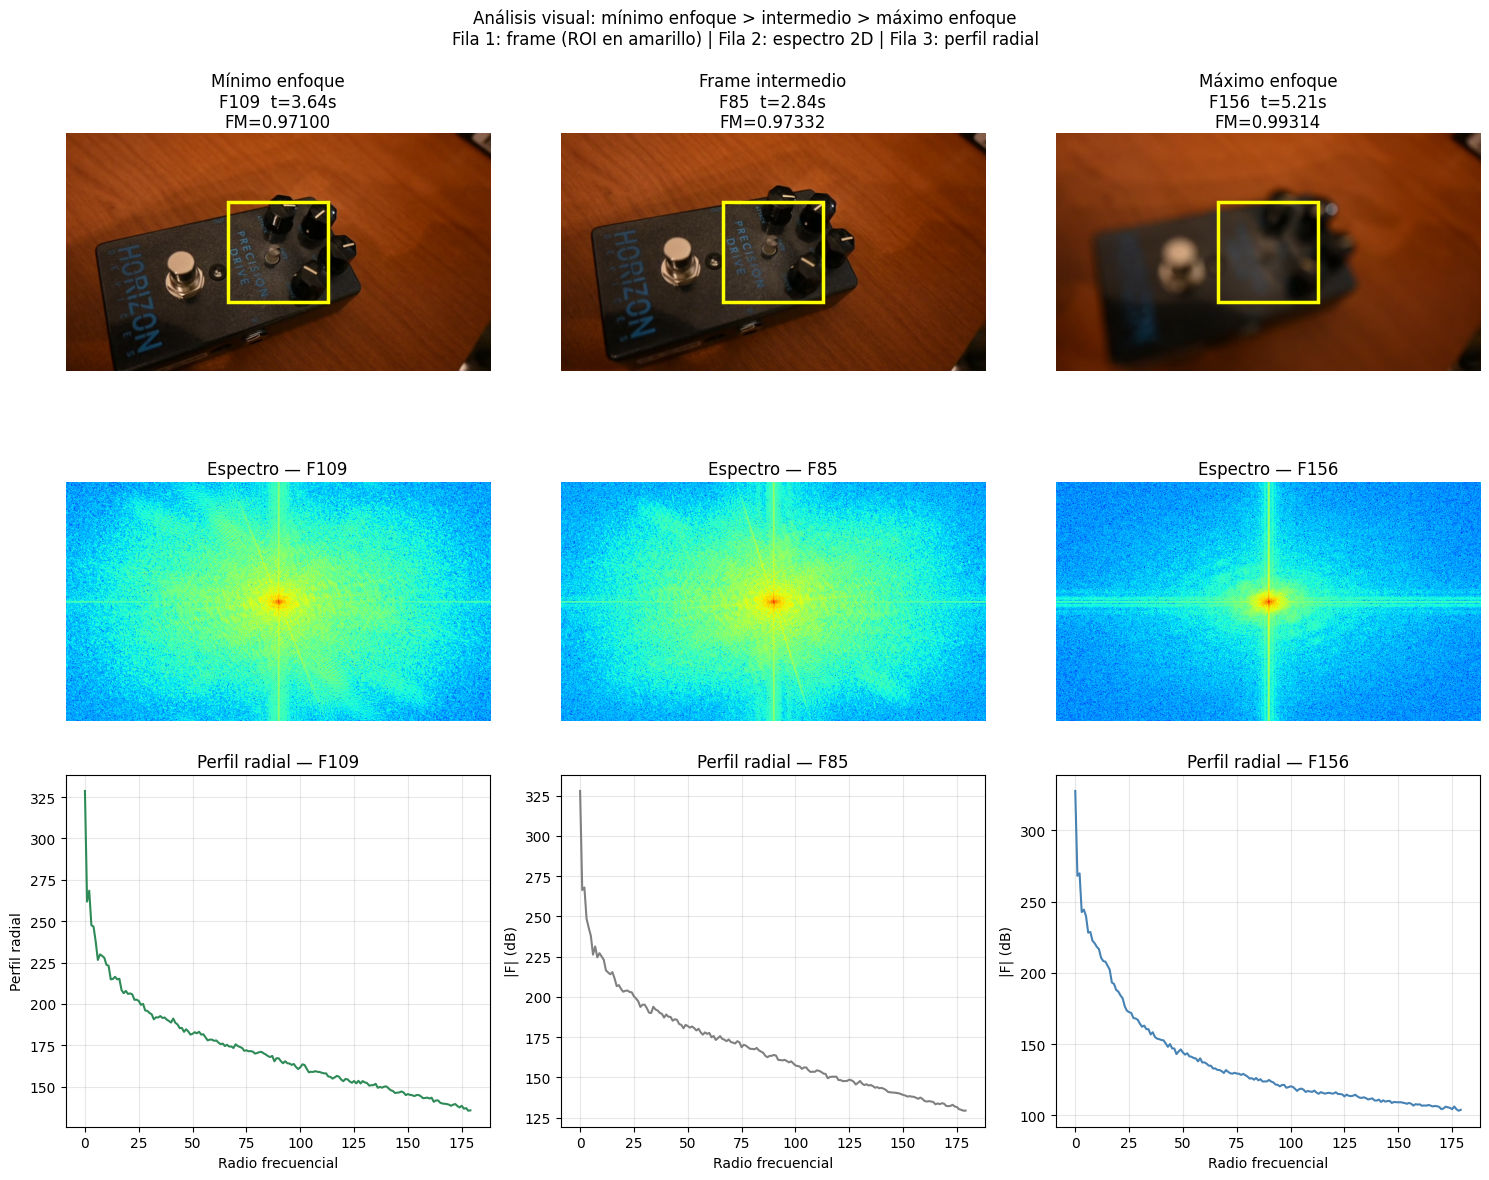

Figura guardada: frames_comparacion.png


In [51]:
def get_frame(video_path, idx):
    cap = cv.VideoCapture(video_path)
    cap.set(cv.CAP_PROP_POS_FRAMES, int(idx))
    ret, f = cap.read()
    cap.release()
    return cv.cvtColor(f, cv.COLOR_BGR2RGB) if ret else None

worst_full = int(metrics_full.argmin())
best_full_i = int(best_full)
mid_frame   = TOTAL_FRAMES // 2

samples = [
    (worst_full,   f'Mínimo enfoque\nF{worst_full}  t={time_axis[worst_full]:.2f}s\nFM={metrics_full[worst_full]:.5f}'),
    (mid_frame,    f'Frame intermedio\nF{mid_frame}  t={time_axis[mid_frame]:.2f}s\nFM={metrics_full[mid_frame]:.5f}'),
    (best_full_i,  f'Máximo enfoque\nF{best_full_i}  t={time_axis[best_full_i]:.2f}s\nFM={metrics_full[best_full_i]:.5f}'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col, (idx, title) in enumerate(samples):
    frame = get_frame(VIDEO_PATH, idx)
    if frame is None: continue

    gray = cv.cvtColor(frame, cv.COLOR_RGB2GRAY)

    # Fila 0: frame con ROI marcada
    axes[0, col].imshow(frame)
    rect = patches.Rectangle((roi_x1, roi_y1), roi_side, roi_side,
                               linewidth=2.5, edgecolor='yellow', facecolor='none')
    axes[0, col].add_patch(rect)
    axes[0, col].set_title(title, pad=4)
    axes[0, col].axis('off')

    # Fila 1: espectro de amplitud (log)
    F   = np.fft.fftshift(np.fft.fft2(gray.astype(np.float64)))
    mag = 20 * np.log(np.abs(F) + 1)
    axes[1, col].imshow(mag, cmap='jet')
    axes[1, col].set_title(f'Espectro — F{idx}')
    axes[1, col].axis('off')

    # Fila 2: perfil radial promedio del espectro
    cy, cx = gray.shape[0]//2, gray.shape[1]//2
    radii = np.sqrt(((np.arange(gray.shape[0])[:,None]-cy)**2 +
                     (np.arange(gray.shape[1])[None,:]-cx)**2))
    max_r = int(min(cy, cx))
    radial = [mag[np.abs(radii - r) < 0.5].mean() if np.any(np.abs(radii-r)<0.5) else 0
              for r in range(max_r)]
    axes[2, col].plot(radial, color='steelblue' if col==2 else ('seagreen' if col==0 else 'gray'), lw=1.5)
    axes[2, col].set_title(f'Perfil radial — F{idx}')
    axes[2, col].set_xlabel('Radio frecuencial')
    axes[2, col].set_ylabel('|F| (dB)')
    axes[2, col].grid(True, alpha=0.3)

axes[0,0].set_ylabel('Frame + ROI (amarillo)')
axes[1,0].set_ylabel('Espectro FFT (log)')
axes[2,0].set_ylabel('Perfil radial')

plt.suptitle('Análisis visual: mínimo enfoque > intermedio > máximo enfoque\n'
             'Fila 1: frame (ROI en amarillo) | Fila 2: espectro 2D | Fila 3: perfil radial')
plt.tight_layout()
plt.savefig('frames_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: frames_comparacion.png')

## 9. Resumen de resultados

In [52]:

print('-RESUMEN DE RESULTADOS')

print(f'Video          : {VIDEO_PATH}')
print(f'Frames totales : {TOTAL_FRAMES}   FPS: {FPS:.2f}    Dur.: {TOTAL_FRAMES/FPS:.2f} s')
print(f'Resolución     : {WIDTH} x {HEIGHT} px')
print(f'Threshold ratio: {THRESHOLD_RATIO}  (parámetro r del paper)')
print(f'ROI central    : {roi_side}×{roi_side} px = {roi_side**2/(WIDTH*HEIGHT)*100:.1f}% del frame')
print()
print(' Experimento 1: Frame completo ')
print(f'  FM mínimo   : {metrics_full.min():.6f}  (frame {metrics_full.argmin()},  t={time_axis[metrics_full.argmin()]:.2f}s)')
print(f'  FM máximo   : {metrics_full.max():.6f}  (frame {metrics_full.argmax()},  t={time_axis[metrics_full.argmax()]:.2f}s)')
print(f'  Picos detect: {len(peaks_full_raw)}')
for p in peaks_full_raw:
    mark = ' !! MÁXIMO!!' if p == best_full else ''
    print(f'    Frame {p:3d}  t={time_axis[p]:.2f}s  FM={metrics_full[p]:.6f}{mark}')
print()
print(f'Experimento 2: ROI central ({ROI_AREA_FRACTION*100:.0f}%) ')
print(f'  FM mínimo   : {metrics_roi.min():.6f}  (frame {metrics_roi.argmin()},  t={time_axis[metrics_roi.argmin()]:.2f}s)')
print(f'  FM máximo   : {metrics_roi.max():.6f}  (frame {metrics_roi.argmax()},  t={time_axis[metrics_roi.argmax()]:.2f}s)')
print(f'  Picos detect: {len(peaks_roi_raw)}')
for p in peaks_roi_raw:
    mark = ' !!MÁXIMO!!' if p == best_roi else ''
    print(f'    Frame {p:3d}  t={time_axis[p]:.2f}s  FM={metrics_roi[p]:.6f}{mark}')


-RESUMEN DE RESULTADOS
Video          : focus_video.mov
Frames totales : 171   FPS: 29.97    Dur.: 5.71 s
Resolución     : 640 x 360 px
Threshold ratio: 0.005  (parámetro r del paper)
ROI central    : 151×151 px = 9.9% del frame

 Experimento 1: Frame completo 
  FM mínimo   : 0.970998  (frame 109,  t=3.64s)
  FM máximo   : 0.993203  (frame 18,  t=0.60s)
  Picos detect: 1
    Frame 156  t=5.21s  FM=0.993141 !! MÁXIMO!!

Experimento 2: ROI central (10%) 
  FM mínimo   : 0.969698  (frame 102,  t=3.40s)
  FM máximo   : 0.996688  (frame 23,  t=0.77s)
  Picos detect: 1
    Frame  23  t=0.77s  FM=0.996688 !!MÁXIMO!!
